In [ ]:
from google.colab import files
files.upload()

In [4]:
import os
os.listdir()

['.config', 'emails.csv', 'sample_data']

In [5]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [6]:
df = pd.read_csv("emails.csv")

In [7]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [12]:
df['spam'].value_counts()

,count
spam,
0,4360
1,1368


In [13]:
df = df.rename(columns={'spam': 'label'})

In [14]:
df.columns

Index(['text', 'label'], dtype='object')

In [15]:
df['label'].value_counts()

,count
label,
0,4360
1,1368


In [16]:
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()  # remove extra spaces
    return text

In [17]:
df['text'] = df['text'].apply(clean_text)

In [18]:
df = df[df['text'].str.strip() != ""]

In [19]:
X = df['text']   # input (email content)
y = df['label']  # output (spam / not spam)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4582
Testing samples: 1146


In [22]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    stop_words='english'
)

In [23]:
X_train_bow = bow_vectorizer.fit_transform(X_train)

In [24]:
X_test_bow = bow_vectorizer.transform(X_test)

In [25]:
print("Training BoW shape:", X_train_bow.shape)
print("Testing BoW shape:", X_test_bow.shape)

Training BoW shape: (4582, 30195)
Testing BoW shape: (1146, 30195)


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95
)

In [28]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [29]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [30]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4582, 30194)
Testing TF-IDF shape: (1146, 30194)


In [31]:
from sklearn.naive_bayes import MultinomialNB

In [32]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

MultinomialNB()

In [33]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [34]:
print("Naive Bayes models trained successfully")

Naive Bayes models trained successfully


In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [36]:
y_pred_bow = nb_bow.predict(X_test_bow)

In [37]:
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

In [38]:
acc_bow = accuracy_score(y_test, y_pred_bow)
print("Bag of Words Accuracy:", acc_bow)

Bag of Words Accuracy: 0.9912739965095986


In [39]:
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print("TF-IDF Accuracy:", acc_tfidf)

TF-IDF Accuracy: 0.9101221640488656


In [40]:
print("Bag of Words Classification Report:")
print(classification_report(y_test, y_pred_bow))

Bag of Words Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.97      0.99      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



In [41]:
print("TF-IDF Classification Report:")
print(classification_report(y_test, y_pred_tfidf))

TF-IDF Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       872
           1       1.00      0.62      0.77       274

    accuracy                           0.91      1146
   macro avg       0.95      0.81      0.86      1146
weighted avg       0.92      0.91      0.90      1146



In [42]:
cm_bow = confusion_matrix(y_test, y_pred_bow)
print("Confusion Matrix - Bag of Words")
print(cm_bow)

Confusion Matrix - Bag of Words
[[865   7]
 [  3 271]]


In [43]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
print("Confusion Matrix - TF-IDF")
print(cm_tfidf)

Confusion Matrix - TF-IDF
[[872   0]
 [103 171]]


In [44]:
from sklearn.naive_bayes import GaussianNB

In [46]:
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

In [47]:
gnb = GaussianNB()
gnb.fit(X_train_tfidf_dense, y_train)

GaussianNB()

In [48]:
y_pred_gnb = gnb.predict(X_test_tfidf_dense)

In [49]:
print("Gaussian Naive Bayes Accuracy:")
print(accuracy_score(y_test, y_pred_gnb))

print("\nGaussian Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_gnb))

Gaussian Naive Bayes Accuracy:
0.9485165794066318

Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       872
           1       0.93      0.85      0.89       274

    accuracy                           0.95      1146
   macro avg       0.94      0.91      0.93      1146
weighted avg       0.95      0.95      0.95      1146



In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

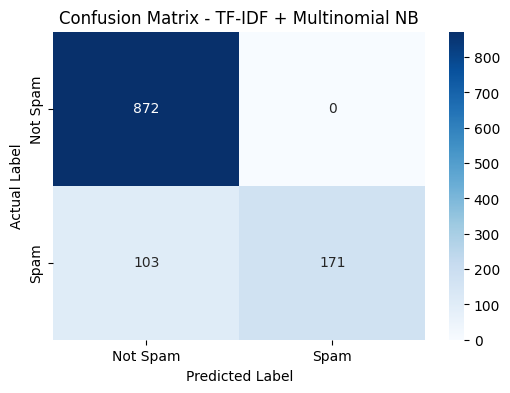

In [52]:
cm = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - TF-IDF + Multinomial NB')
plt.show()

In [53]:
y_prob = nb_tfidf.predict_proba(X_test_tfidf)[:, 1]

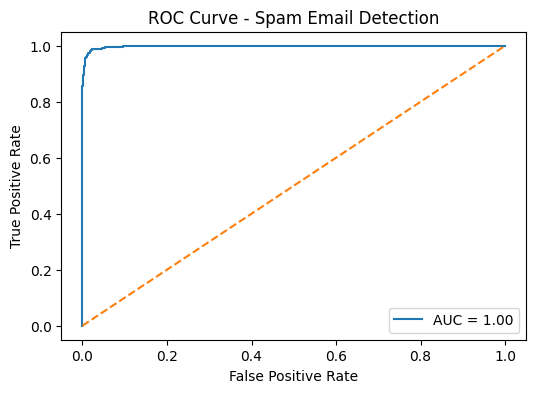

In [54]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Spam Email Detection')
plt.legend(loc='lower right')
plt.show()

In [55]:
new_emails = [
    "Congratulations! You have won a free lottery. Claim your prize now.",
    "Dear student, your assignment submission deadline is tomorrow.",
    "Limited offer! Buy now and get 50% discount.",
    "Meeting scheduled at 10 AM tomorrow with the project team."
]

In [60]:
new_emails_tfidf = tfidf_vectorizer.transform(new_emails)
predictions = nb_tfidf.predict(new_emails_tfidf)

for email, pred in zip(new_emails, predictions):
    label = "Spam" if pred == 1 else "Not Spam"
    print(f"Email: {email}\nPrediction: {label}\n")

Email: Congratulations! You have won a free lottery. Claim your prize now.
Prediction: Not Spam

Email: Dear student, your assignment submission deadline is tomorrow.
Prediction: Not Spam

Email: Limited offer! Buy now and get 50% discount.
Prediction: Not Spam

Email: Meeting scheduled at 10 AM tomorrow with the project team.
Prediction: Not Spam

